# **Problem Statement**

## **Business Context**

Workplace safety in hazardous environments like construction sites and industrial plants is crucial to prevent accidents and injuries. One of the most important safety measures is ensuring workers wear safety helmets, which protect against head injuries from falling objects and machinery. Non-compliance with helmet regulations increases the risk of serious injuries or fatalities, making effective monitoring essential, especially in large-scale operations where manual oversight is prone to errors and inefficiency.

To overcome these challenges, SafeGuard Corp plans to develop an automated image analysis system capable of detecting whether workers are wearing safety helmets. This system will improve safety enforcement, ensuring compliance and reducing the risk of head injuries. By automating helmet monitoring, SafeGuard aims to enhance efficiency, scalability, and accuracy, ultimately fostering a safer work environment while minimizing human error in safety oversight.

## **Objective**

As a data scientist at SafeGuard Corp, you are tasked with developing an image classification model that classifies images into one of two categories:
- **With Helmet:** Workers wearing safety helmets.
- **Without Helmet:** Workers not wearing safety helmets.

## **Data Description**

The dataset consists of **4125 images**, divided into two categories:

- **With Helmet:** 3161 images showing workers wearing helmets.
- **Without Helmet:** 964 images showing workers not wearing helmets.

**Dataset Characteristics:**
- **Variations in Conditions:** Images include diverse environments such as construction sites, factories, and industrial settings, with variations in lighting, angles, and worker postures to simulate real-world conditions.
- **Worker Activities:** Workers are depicted in different actions such as standing, using tools, or moving, ensuring robust model learning for various scenarios.

# **Installing and Importing the Necessary Libraries**

In [1]:
!pip install tensorflow[and-cuda] scikit-learn==1.6.1 opencv-python==4.12.0.88 seaborn==0.13.2 matplotlib==3.10.0 numpy==2.0.2 pandas==2.2.2 -q

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [1]:
import os
import random
import numpy as np                                                                               # Importing numpy for Matrix Operations
import pandas as pd
import seaborn as sns
import matplotlib.image as mpimg                                                                              # Importing pandas to read CSV files
import matplotlib.pyplot as plt                                                                  # Importting matplotlib for Plotting and visualizing images
import math                                                                                      # Importing math module to perform mathematical operations
import cv2


# Tensorflow modules
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              # Importing the ImageDataGenerator for data augmentation
from tensorflow.keras.models import Sequential                                                   # Importing the sequential module to define a sequential model
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization # Defining all the layers to build our CNN Model
from tensorflow.keras.optimizers import Adam,SGD                                                 # Importing the optimizers which can be used in our model
from sklearn import preprocessing                                                                # Importing the preprocessing module to preprocess the data
from sklearn.model_selection import train_test_split                                             # Importing train_test_split function to split the data into train and test
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16                                               # Importing confusion_matrix to plot the confusion matrix

# Display images using OpenCV
from google.colab.patches import cv2_imshow

#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse                                                 # Importing cv2_imshow from google.patches to display images

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.__version__)

Num GPUs Available: 1
2.19.0


In [3]:
# 1. Set Python random seed
random.seed(812)

# 2. Set NumPy random seed
np.random.seed(812)

# 3. Set TensorFlow seed (covers Keras + backend)
tf.keras.utils.set_random_seed(812)

# 4. Enable deterministic GPU ops (if using GPU)
tf.config.experimental.enable_op_determinism()

# **Data Overview**


##Loading the data

In [4]:
images = np.load('sample_data/images.npy')

labels = pd.read_csv('sample_data/labels.csv')

In [75]:
labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4125 entries, 0 to 4124
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   4125 non-null   int64
dtypes: int64(1)
memory usage: 32.4 KB


In [ ]:
# Observation : All 4125 rows are non-null . there are no missing values in the label.
# The labels are stored as int64 which is for binry classification 0 and 1.

In [77]:
feature_counts = labels['label'].value_counts()
print(feature_counts)

label
1    3161
0     964
Name: count, dtype: int64


In [ ]:
# Observation 76.6% of data are with helmet, classified as 1.
# 23.4% of data are without helmet , classifoed as 0.

In [5]:
print(images.shape)
print(labels.shape)

(4125, 200, 200, 3)
(4125, 1)


In [ ]:
# Observation : There are 4125 images with 200 Height * 200 width of each image in pixels. The 3 represents the RBG color

In [ ]:
# Observation  : This is the 4125 number of samples (or rows) in your dataset.
# There is the 1 features for each label.

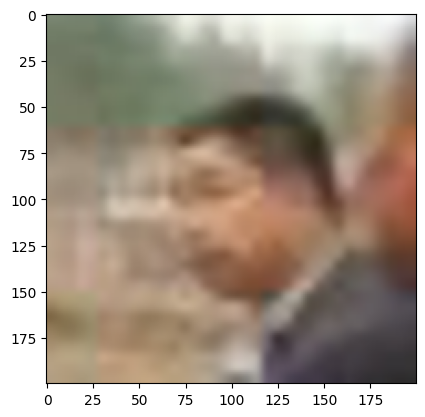

In [78]:
# Display images[0] with MatplotLib
plt.imshow(images[0])
plt.show()

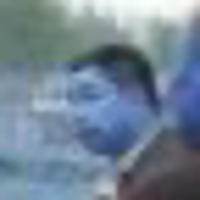

In [81]:
# Display images[0] with cv2_imshow()
cv2_imshow(images[0])

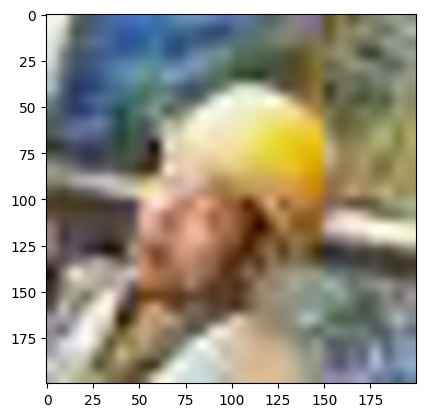

In [80]:
# Display images[] with MatplotLib
plt.imshow(images[4124])
plt.show()

In [ ]:
# Observation : The images are in RBG color space.

# **Exploratory Data Analysis**

###Plot random images from each of the classes and print their corresponding labels.

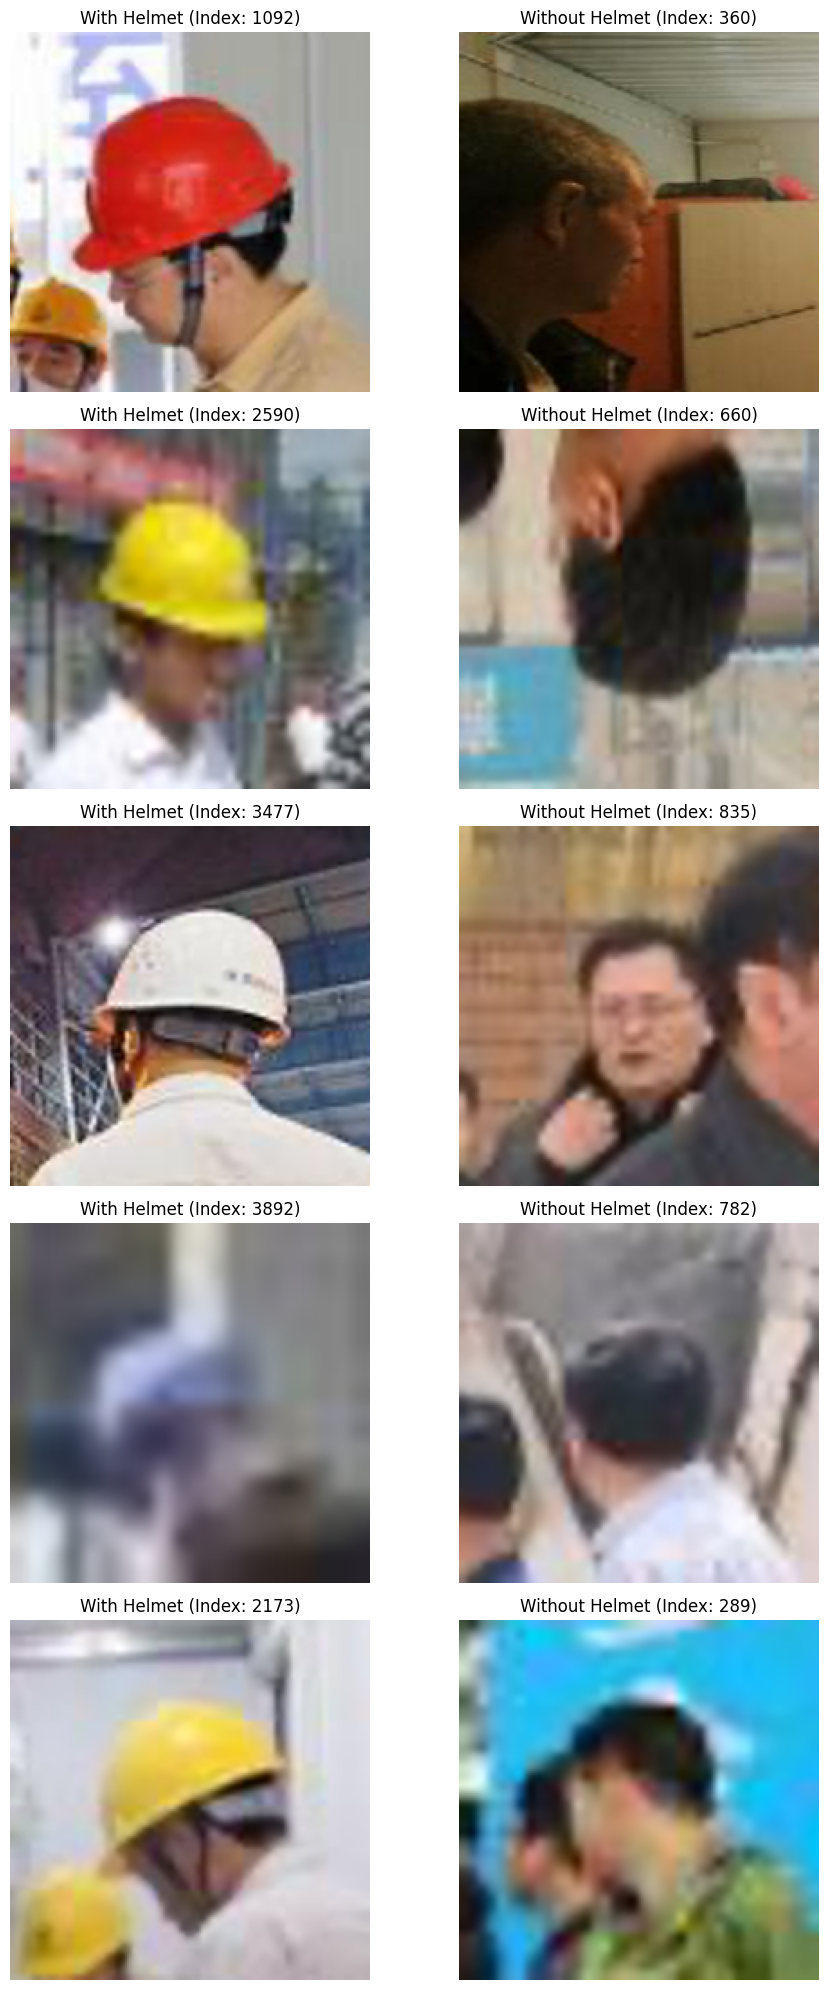

In [6]:
# Get indices for 'With Helmet' (label 1) and 'Without Helmet' (label 0)
helmet_indices = labels[labels.iloc[:, 0] == 1].index.tolist()
no_helmet_indices = labels[labels.iloc[:, 0] == 0].index.tolist()

# Select 5 random indices from each class
num_samples_to_plot = 5
random_helmet_idxs = random.sample(helmet_indices, num_samples_to_plot)
random_no_helmet_idxs = random.sample(no_helmet_indices, num_samples_to_plot)

fig, axes = plt.subplots(num_samples_to_plot, 2, figsize=(10, 4 * num_samples_to_plot))

for i in range(num_samples_to_plot):
    # Plot 'With Helmet' images
    axes[i][0].imshow(images[random_helmet_idxs[i]])
    axes[i][0].set_title(f"With Helmet (Index: {random_helmet_idxs[i]})")
    axes[i][0].axis("off")

    # Plot 'Without Helmet' images
    axes[i][1].imshow(images[random_no_helmet_idxs[i]])
    axes[i][1].set_title(f"Without Helmet (Index: {random_no_helmet_idxs[i]})")
    axes[i][1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Observation : Exploratory Data Analysis (EDA) shows visualizing random samples from your two classes.
# Class 1 (With Helmet) and Class 0 (Without Helmet) .
# Indices 1092, 2590, 3477, 3892  are classified as class 1 with Helmet.
# Indices 360,660,835,782 and 289 are classified as class 2 without Helmet.


## Checking for class imbalance


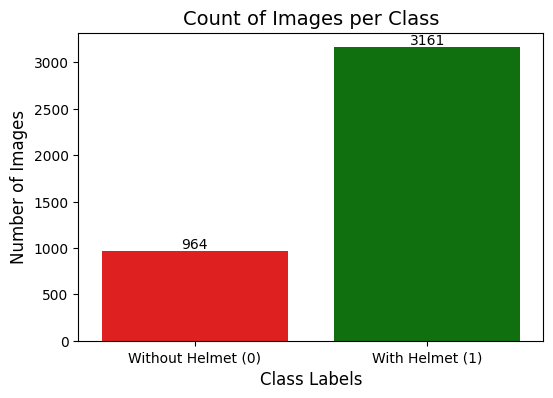

In [7]:
# Create a count plot
plt.figure(figsize=(6, 4))
ax = sns.countplot(x=labels.iloc[:, 0], palette=['red', 'green'])

# Add exact counts on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10, )

# Add labels
plt.xlabel("Class Labels", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.title("Count of Images per Class", fontsize=14)
plt.xticks(ticks=[0, 1], labels=["Without Helmet (0)", "With Helmet (1)"])  # Rename x-axis labels

# Show plot
plt.show()

In [ ]:
# Observation There is a clear disparity between the two categories.

# With Helmet (1): 3,161 images.

# Without Helmet (0): 964 images.

In [ ]:
# The "Without Helmet" class is much smaller, which is a common challenge in safety datasets.

# **Data Preprocessing**

### Splitting the dataset



In [8]:
X_train, X_temp, y_train, y_temp = train_test_split(np.array(images),labels , test_size=0.30, random_state=42,stratify=labels)
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp , test_size=0.50, random_state=42,stratify=y_temp)

In [9]:
print(X_train.shape,y_train.shape)
print(X_val.shape,y_val.shape)
print(X_test.shape,y_test.shape)

(2887, 200, 200, 3) (2887, 1)
(619, 200, 200, 3) (619, 1)
(619, 200, 200, 3) (619, 1)


In [10]:
# Observation :
# Using a 70-15-15 split.

# 70% Training: 2,887 images (used to train the model).

# 15% Validation: 619 images (used to tune hyperparameters and prevent overfitting).

# 15% Test: 619 images (used for the final "unseen" evaluation).

In [11]:
# Observation :
# The code uses stratify=labels. This ensures that the class imbalance (76% with helmet, 24% without) is maintained across all three sets.
# Without this, you might accidentally end up with a Test set that has no "Without Helmet" examples at all.

### Encoding the target labels

In [12]:
# Convert labels from names to one hot vectors.
# We have already used encoding methods like onehotencoder and labelencoder earlier so now we will be using a new encoding method called labelBinarizer.
# Labelbinarizer works similar to onehotencoder

from sklearn.preprocessing import LabelBinarizer
enc = LabelBinarizer()
y_train_encoded = enc.fit_transform(y_train)
y_val_encoded=enc.transform(y_val)
y_test_encoded=enc.transform(y_test)

### Data Normalization

In [13]:
X_train_normalized = X_train.astype('float32')/255
X_val_normalized = X_val.astype('float32')/255
X_test_normalized = X_test.astype('float32')/255

In [ ]:
# Observation : Since the image pixel values range from 0-255, our method of normalization here will be scaling - we shall divide all the pixel values by 255 to standardize the images to have values between 0-1.

# **Model Building**

##Model Evaluation Criterion

## Utility Functions

In [15]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)


    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='micro')  # to compute Recall
    precision = precision_score(target, pred, average='micro')  # to compute Precision
    f1 = f1_score(target, pred, average='micro')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[0],)

    return df_perf

In [16]:
def plot_confusion_matrix(model,predictors,target,ml=False):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable
    ml: To specify if the model used is an sklearn ML model or not (True means ML model)
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)

    # Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
    confusion_matrix = tf.math.confusion_matrix(target,pred)
    f, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        confusion_matrix,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax
    )
    plt.show()

##Model 1: Convolutional Neural Network (CNN) from Scratch

In [17]:
# Initializing Model
model_1 = Sequential()

# Convolutional layers
model_1.add(Conv2D(16, (3, 3), activation='relu', padding="same", input_shape=(200,200,3)))
model_1.add(MaxPooling2D((4, 4), padding='same'))
model_1.add(Conv2D(32, (2, 2), activation='relu', padding="same"))
model_1.add(MaxPooling2D((2,2), padding='same'))
model_1.add(Conv2D(64, (3,3), activation='relu', padding="same"))

# Flatten and Dense layers
model_1.add(Flatten())
model_1.add(Dense(4, activation='relu'))
model_1.add(Dense(1, activation='sigmoid'))

In [ ]:
# Observations :
# First layer extracts basic features like edges and textures.
# Second layer reduces image size and keeps important features.
# Third layer learns more complex patterns like helmet shapes.
# Forth Layer further reduces spatial size and prevents overfitting .
# Fifth layer Captures deeper features and finer details.

# Later flattening the image to convert from Converts 2D feature maps into 1D vector.

# Output layer for binary classification (helmet / no helmet) using sigmoid activcation function.


In [18]:
# Compile with Adam Optimizer
opt = Adam(learning_rate=0.001)

In [ ]:
# Observation: Compiling the model with Adam Optimizer
# Learning rate controls how fast the model learns

In [19]:
model_1.compile(optimizer=opt, loss='binary_crossentropy', metrics=["Recall"])

In [20]:
# Summary
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 200, 200, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 32)     │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 40000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │       160,004 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 181,033 (707.16 KB)

 Trainable params: 181,033 (707.16 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history_1 = model_1.fit(
            X_train_normalized, y_train,
            epochs=10,
            validation_data=(X_val_normalized,y_val),
            shuffle=True,
            batch_size=32,
            verbose=2
)

Epoch 1/10
91/91 - 8s - 87ms/step - Recall: 0.9815 - loss: 0.4194 - val_Recall: 0.9747 - val_loss: 0.3022
Epoch 2/10
91/91 - 2s - 26ms/step - Recall: 0.9512 - loss: 0.2936 - val_Recall: 0.9642 - val_loss: 0.2824
Epoch 3/10
91/91 - 2s - 25ms/step - Recall: 0.9426 - loss: 0.2748 - val_Recall: 0.9663 - val_loss: 0.2722
Epoch 4/10
91/91 - 2s - 25ms/step - Recall: 0.9403 - loss: 0.2620 - val_Recall: 0.9768 - val_loss: 0.2771
Epoch 5/10
91/91 - 2s - 24ms/step - Recall: 0.9426 - loss: 0.2507 - val_Recall: 0.9789 - val_loss: 0.2906
Epoch 6/10
91/91 - 2s - 24ms/step - Recall: 0.9458 - loss: 0.2430 - val_Recall: 0.9768 - val_loss: 0.2953
Epoch 7/10
91/91 - 2s - 25ms/step - Recall: 0.9476 - loss: 0.2300 - val_Recall: 0.9832 - val_loss: 0.2941
Epoch 8/10
91/91 - 2s - 26ms/step - Recall: 0.9494 - loss: 0.2221 - val_Recall: 0.9832 - val_loss: 0.2931
Epoch 9/10
91/91 - 2s - 27ms/step - Recall: 0.9507 - loss: 0.2150 - val_Recall: 0.9811 - val_loss: 0.2582
Epoch 10/10
91/91 - 3s - 36ms/step - Recall: 0

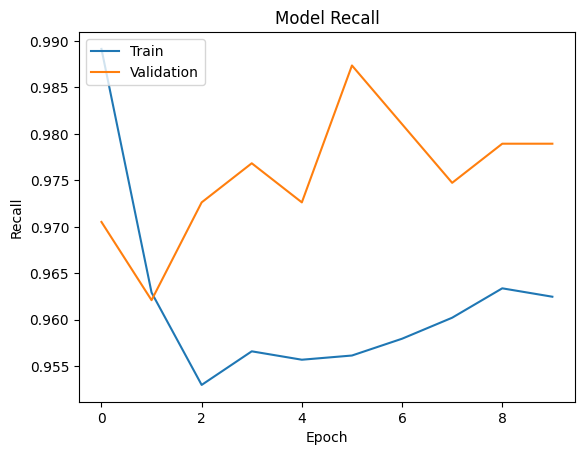

In [28]:
# Plotting
plt.plot(history_1.history['Recall'])
plt.plot(history_1.history['val_Recall'])
plt.title('Model Recall')
plt.ylabel('Recall')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [33]:
#Observation :
# After an initial dip in training test data , recall stablizes and reaches around 96% , suggesting the model is learning rather than guessing.
# The validation recall , orange line has more fluctuation.

#By epoch 10, the training and validation recall values are very close to each other.

In [60]:
model_1_train_perf = model_performance_classification(model_1, X_train_normalized,y_train)

print("Train performance metrics")
print(model_1_train_perf)

91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.930031  0.930031   0.930031  0.930031


In [ ]:
#Observation : The model achieves a balanced performance across all metrics (Accuracy, Recall, Precision, and F1-Score) at approximately 93.0%.

91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step


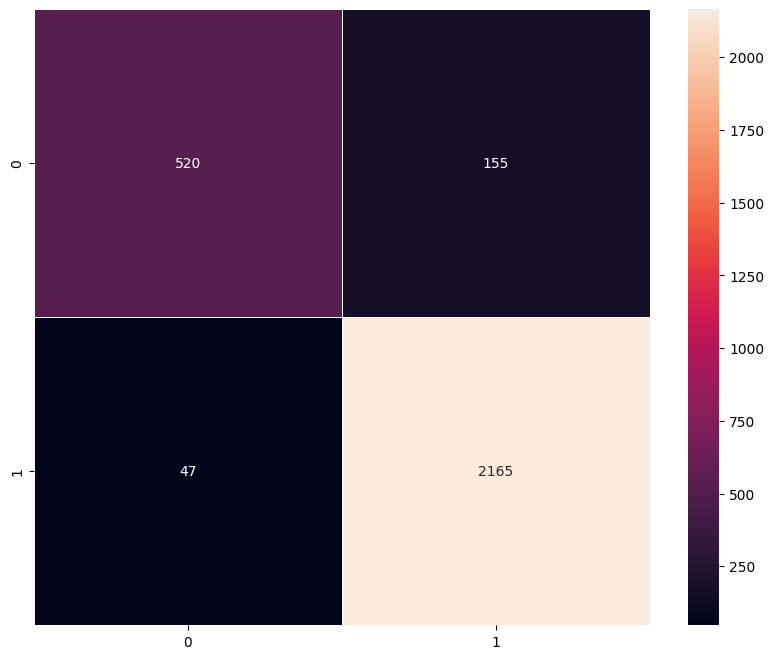

In [61]:
plot_confusion_matrix(model_1,X_train_normalized,y_train)

In [ ]:
#Observation :
# True positive -  There are 2165 imagres where workers were wering helmets and the model correctly identified.
# True Negative - There are 520 iamges where the workers were not wearing helmets and the model correctly identified them as not having helmets.
# Fale Negative - For 47 images, the model said no helmet but they had one .
# False positive - For 155 images, the model said with helmet but there didn't have one.

# The 155 False Positives are your biggest concern, as those are workers without helmets that the system let "slide" by mistake.

In [62]:
model_1_valid_perf = model_performance_classification(model_1, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_1_valid_perf)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.914378  0.914378   0.914378  0.914378


In [ ]:
#Observation : There is a slight performance drop as compared to the training dataset.
#The model achieves a balanced performance across all metrics (Accuracy, Recall, Precision, and F1-Score) at approximately 91.4%.

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


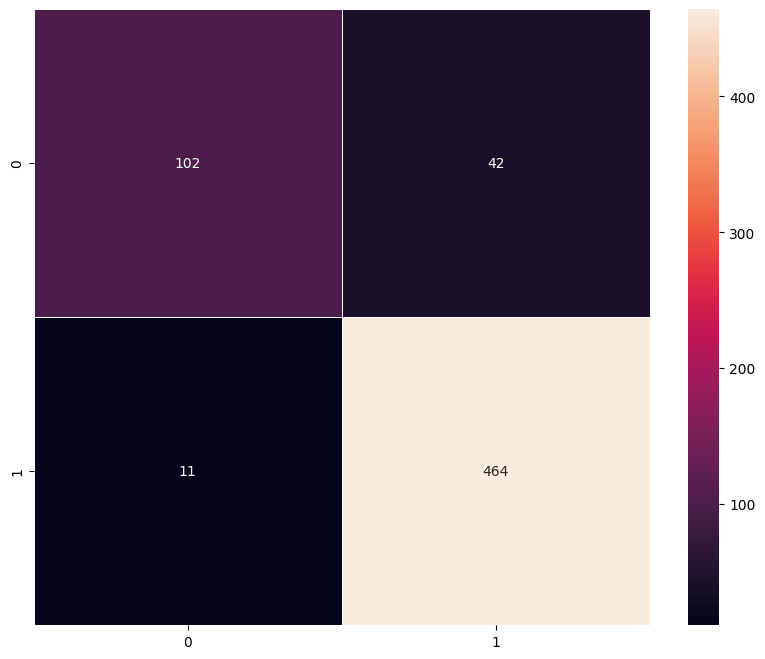

In [63]:
plot_confusion_matrix(model_1,X_val_normalized,y_val)

In [ ]:
#Observation :
# True positive - There are 464 imagres where workers were wering helmets and the model correctly identified.
# True Negative - There are 104 iamges where the workers were not wearing helmets and the model correctly identified them as not having helmets.
# Fale Negative - For 11 images, the model said no helmet but they had one .
# False positive - For 412images, the model said with helmet but there didn't have one.

# The 42 False Positives are your biggest concern.  In a real-world deployment, as these 41 people who would be allowed onto a site without protection because the AI mistakenly thought they were wearing a helmet.

### Visualizing the predictions

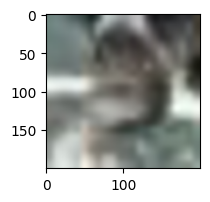

Predicted Label: 0
True Label: 0


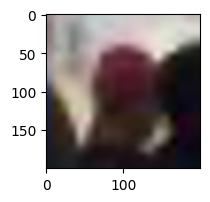

Predicted Label: 1
True Label: 1


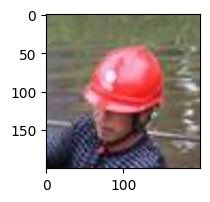

Predicted Label: 1
True Label: 1


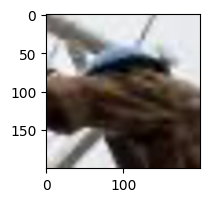

Predicted Label: 1
True Label: 1


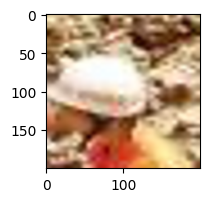

Predicted Label: 1
True Label: 1


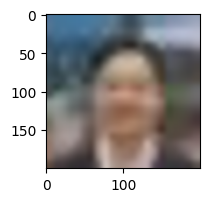

Predicted Label: 1
True Label: 0


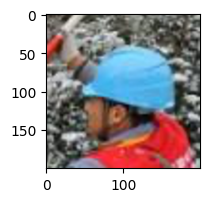

Predicted Label: 1
True Label: 1


In [66]:
# For index 12
# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[12])
plt.show()
pred_12 = (model_1.predict(X_val_normalized[12].reshape(1,200,200,3), verbose=0) > 0.5).astype(int)
print('Predicted Label:', enc.inverse_transform(pred_12)[0])
print('True Label:', enc.inverse_transform(y_val_encoded)[12])

# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[33])
plt.show()
pred_33 = (model_1.predict(X_val_normalized[33].reshape(1,200,200,3), verbose=0) > 0.5).astype(int)
print('Predicted Label:', enc.inverse_transform(pred_33)[0])
print('True Label:', enc.inverse_transform(y_val_encoded)[33])

# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[2])
plt.show()
pred_2 = (model_1.predict(X_val_normalized[33].reshape(1,200,200,3), verbose=0) > 0.5).astype(int)
print('Predicted Label:', enc.inverse_transform(pred_2)[0])
print('True Label:', enc.inverse_transform(y_val_encoded)[2])

# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[100])
plt.show()
pred_100 = (model_1.predict(X_val_normalized[100].reshape(1,200,200,3), verbose=0) > 0.5).astype(int)
print('Predicted Label:', enc.inverse_transform(pred_100)[0])
print('True Label:', enc.inverse_transform(y_val_encoded)[100])

# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[200])
plt.show()
pred_200 = (model_1.predict(X_val_normalized[33].reshape(1,200,200,3), verbose=0) > 0.5).astype(int)
print('Predicted Label:', enc.inverse_transform(pred_200)[0])
print('True Label:', enc.inverse_transform(y_val_encoded)[200])

# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[289])
plt.show()
pred_289 = (model_1.predict(X_val_normalized[289].reshape(1,200,200,3), verbose=0) > 0.5).astype(int)
print('Predicted Label:', enc.inverse_transform(pred_200)[0])
print('True Label:', enc.inverse_transform(y_val_encoded)[289])

# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[360])
plt.show()
pred_360 = (model_1.predict(X_val_normalized[33].reshape(1,200,200,3), verbose=0) > 0.5).astype(int)
print('Predicted Label:', enc.inverse_transform(pred_360)[0])
print('True Label:', enc.inverse_transform(y_val_encoded)[360])


In [61]:
#Observation

# The model shows generally good performance, correctly classifying most images where helmets are clearly visible.

# For indices 2, 100, 200, and 360, the model successfully detected helmets, indicating that it performs well on clear and well-defined images.

# At index 289, the model correctly identified the absence of a helmet, showing its ability to detect safety violations accurately.

# However, there are some critical errors:

  #At index 12, the model produced a false positive, predicting a helmet where none was present. This is a serious safety concern, as violations may go unnoticed.
  #At index 33, the model produced a false negative, missing an actual helmet. This may be due to image angle, lighting, or low contrast, affecting feature extraction.

# Overall, the model performs well under ideal conditions but struggles with challenging visual scenarios, highlighting the need for improvement in handling variations in lighting, angle, and image quality.


## Model 2: Transfer Learning with VGG-16 (Base)

- We will be loading a pre-built architecture - **VGG16**, which was trained on the ImageNet dataset and is the runner-up in the ImageNet competition in 2014.

- For training VGG16, we will directly use the convolutional and pooling layers and freeze their weights i.e. no training will be done on them. For classification, we will add a Flatten and a single dense layer.


In [22]:
vgg_model = VGG16(weights='imagenet',include_top=False,input_shape=(200,200,3))
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 200, 200, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 200, 200, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 100, 100, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 100, 100, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 50, 50, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 25, 25, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# Making all the layers of the VGG model non-trainable. i.e. freezing them
for layer in vgg_model.layers:
    layer.trainable = False

In [25]:
model_2 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_2.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_2.add(Flatten())

# Adding a dense output layer
model_2.add(Dense(1, activation='sigmoid'))

In [26]:
opt=Adam(learning_rate=0.001)
# Compile model
model_2.compile(optimizer=opt, loss=keras.losses.BinaryCrossentropy(), metrics=["Recall"])

In [27]:
# Generating the summary of the model
model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │        18,433 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,733,121 (56.20 MB)

 Trainable params: 18,433 (72.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [28]:
train_datagen = ImageDataGenerator()

In [29]:
# Epochs
epochs = 10
# Batch size
batch_size = 32

history_2 = model_2.fit(train_datagen.flow(X_train_normalized,y_train,
                                      batch_size=batch_size,
                                      seed=42,
                                      shuffle=False),
                    epochs=epochs,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 19s 202ms/step - Recall: 0.9278 - loss: 0.4174 - val_Recall: 0.9200 - val_loss: 0.3250
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - Recall: 1.0000 - loss: 0.2387 - val_Recall: 0.9411 - val_loss: 0.3168
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 15s 172ms/step - Recall: 0.9703 - loss: 0.2404 - val_Recall: 0.9053 - val_loss: 0.2786
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - Recall: 0.9565 - loss: 0.2373 - val_Recall: 0.8989 - val_loss: 0.2811
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 15s 165ms/step - Recall: 0.9771 - loss: 0.1947 - val_Recall: 0.9579 - val_loss: 0.2585
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - Recall: 0.9600 - loss: 0.1619 - val_Recall: 0.9663 - val_loss: 0.2625
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 15s 166ms/step - Recall: 0.9749 - loss: 0.1700 - val_Recall: 0.9705 - val_loss: 0.2764
Epoch 8/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - Recall: 1.0000 - loss: 0.0766 - val_Recall: 0.9663 - val_loss: 0.2687
Epoch 9/

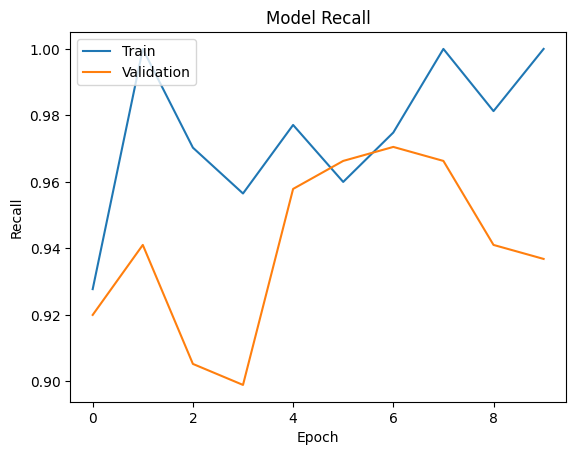

In [30]:
plt.plot(history_2.history['Recall']) #Complete the code to plot the train metrics
plt.plot(history_2.history['val_Recall']) #Complete the code to plot the validation data metrics
plt.title('Model Recall') #Complete the code to define the title for the plot
plt.ylabel('Recall') #Complete the code to define the label for the y-axis
plt.xlabel('Epoch') #Complete the code to define the label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


In [ ]:
#Observation :
# The model achieves a perfect 1.0000 Recall on the training set, indicating it has completely memorized the "With Helmet" patterns in the training data.
# There is a noticeable drop to 0.90 in Validation Recall, creating a 6.32% gap that signals significant overfitting.
# The fluctuating logs (hitting 1.0, dipping, then returning to 1.0) suggest the model is unstable

In [31]:
model_2_train_perf = model_performance_classification(model_2,X_train_normalized,y_train)

print("Train performance metrics")
print(model_2_train_perf)

91/91 ━━━━━━━━━━━━━━━━━━━━ 16s 149ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.965016  0.965016   0.965016  0.965016


In [ ]:
#Observation : The model achieves a balanced performance across all metrics (Accuracy, Recall, Precision, and F1-Score) at approximately 96.5%.

91/91 ━━━━━━━━━━━━━━━━━━━━ 14s 141ms/step


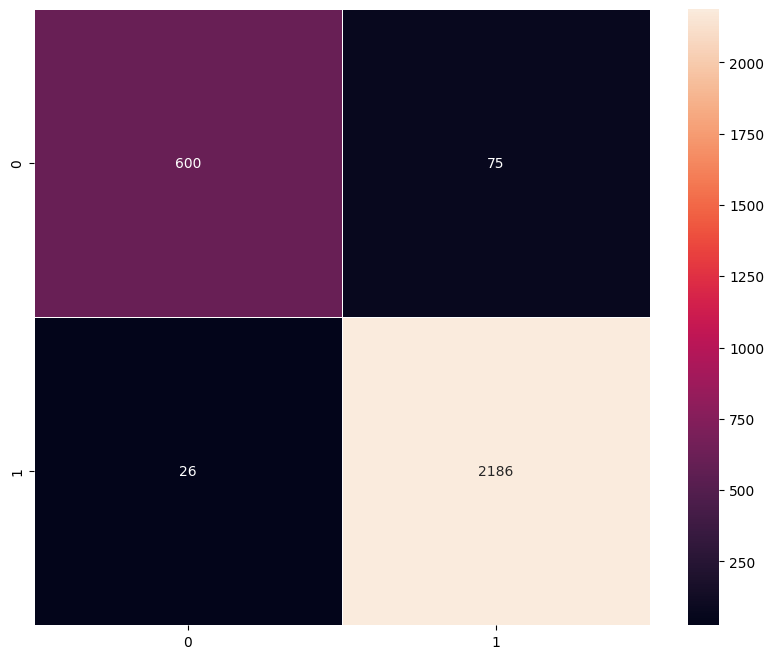

In [32]:
plot_confusion_matrix(model_2,X_train_normalized,y_train)

In [ ]:
#Observation :
# True positive - There are 2186 images where workers were wering helmets and the model correctly identified.
# True Negative - There are 600 iamges where the workers were not wearing helmets and the model correctly identified them as not having helmets.
# False Negative - For 26 images, the model said no helmet but they had one .
# False positive - For 75 images, the model said with helmet but there didn't have one.

# The 75 False Positives are your biggest concern.  In a real-world deployment, as these 75 people who would be allowed onto a site without protection because the AI mistakenly thought they were wearing a helmet.

In [33]:
model_2_valid_perf = model_performance_classification(model_2, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_2_valid_perf)

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.878837  0.878837   0.878837  0.878837


In [ ]:
#Observation : A significant drop as compared to the training data from 96.5% to 87.8%

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 141ms/step


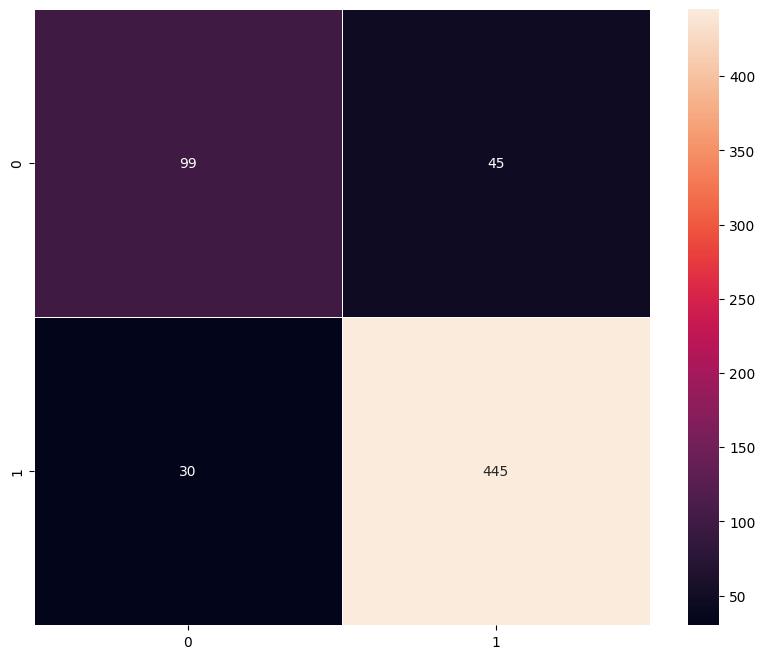

In [34]:
plot_confusion_matrix(model_2,X_val_normalized,y_val)

In [ ]:
#Observation :
# True positive - There are 445 images where workers were wering helmets and the model correctly identified.
# True Negative - There are 99 iamges where the workers were not wearing helmets and the model correctly identified them as not having helmets.
# False Positive - For 45 images without helmets were mistakenly labeled "With Helmet."
# False Negative - For 30 images wearing helmets were labeled "Without Helmet."

# The 45 False Positives are your biggest concern.  In a real-world deployment, as these 45 people who would be allowed onto a site without protection because the AI mistakenly thought they were wearing a helmet.

### Visualizing the predictions

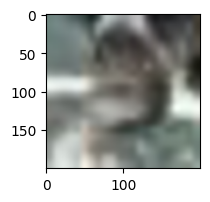

Predicted Label: 1
True Label: 0


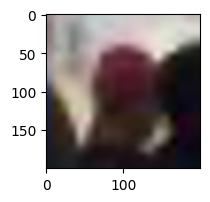

Predicted Label: 1
True Label: 1


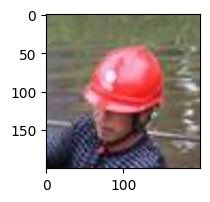

Predicted Label: 1
True Label: 1


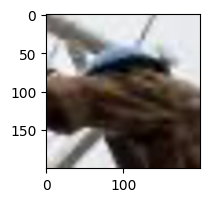

Predicted Label: 0
True Label: 1


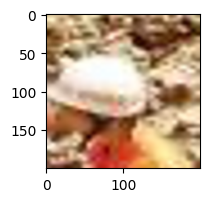

Predicted Label: 1
True Label: 1


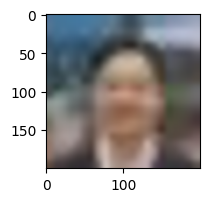

Predicted Label: 1
True Label: 0


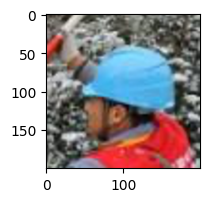

Predicted Label: 1
True Label: 1


In [83]:
# For index 12
# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[12])
plt.show()
pred_12 = (model_2.predict(X_val_normalized[12].reshape(1,200,200,3), verbose=0) > 0.5).astype(int)
print('Predicted Label:', enc.inverse_transform(pred_12)[0])
print('True Label:', enc.inverse_transform(y_val_encoded)[12])

# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[33])
plt.show()
pred_33 = (model_2.predict(X_val_normalized[33].reshape(1,200,200,3), verbose=0) > 0.5).astype(int)
print('Predicted Label:', enc.inverse_transform(pred_33)[0])
print('True Label:', enc.inverse_transform(y_val_encoded)[33])

# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[2])
plt.show()
pred_2 = (model_2.predict(X_val_normalized[33].reshape(1,200,200,3), verbose=0) > 0.5).astype(int)
print('Predicted Label:', enc.inverse_transform(pred_2)[0])
print('True Label:', enc.inverse_transform(y_val_encoded)[2])

# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[100])
plt.show()
pred_100 = (model_2.predict(X_val_normalized[100].reshape(1,200,200,3), verbose=0) > 0.5).astype(int)
print('Predicted Label:', enc.inverse_transform(pred_100)[0])
print('True Label:', enc.inverse_transform(y_val_encoded)[100])

# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[200])
plt.show()
pred_200 = (model_2.predict(X_val_normalized[33].reshape(1,200,200,3), verbose=0) > 0.5).astype(int)
print('Predicted Label:', enc.inverse_transform(pred_200)[0])
print('True Label:', enc.inverse_transform(y_val_encoded)[200])

# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[289])
plt.show()
pred_289 = (model_2.predict(X_val_normalized[289].reshape(1,200,200,3), verbose=0) > 0.5).astype(int)
print('Predicted Label:', enc.inverse_transform(pred_200)[0])
print('True Label:', enc.inverse_transform(y_val_encoded)[289])

# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[360])
plt.show()
pred_360 = (model_2.predict(X_val_normalized[33].reshape(1,200,200,3), verbose=0) > 0.5).astype(int)
print('Predicted Label:', enc.inverse_transform(pred_360)[0])
print('True Label:', enc.inverse_transform(y_val_encoded)[360])




In [ ]:
#Observation: Model 2 is performing worse than model 1. There is lot of inconsistency.
# For the indices 33,289,360 the the model predicated with helmet but the image have helmet.
#For the index 100 , the image shows helmet but the model predicated no helmet
#For the index 12, the image show no helmet, but the model predicted with helmet.

## Model 3: Transfer Learning with VGG-16 (Base + FFNN)





In [36]:
model_3 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_3.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_3.add(Flatten())

#Adding the Feed Forward neural network
model_3.add(Dense(256,activation='relu'))
model_3.add(Dropout(rate=0.4))
model_3.add(Dense(32,activation='relu'))

# Adding a dense output layer
model_3.add(Dense(1, activation='sigmoid'))

In [ ]:
#Observation : Adding 2 feedforward layer to the existing trained VGG16.
# Adding the custom Feed-Forward head (Dense 256 -> Dropout -> Dense 32) allows the model to repurpose high-level VGG-16 features for the specific binary task of helmet detection.

In [37]:
opt = Adam(learning_rate=0.001)

In [38]:
# Compile model
model_3.compile(optimizer=opt,loss=keras.losses.BinaryCrossentropy(), metrics=["Recall"])

In [39]:
# Generating the summary of the model
model_3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,441,793 (74.16 MB)

 Trainable params: 4,727,105 (18.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [40]:
history_3 = model_3.fit(train_datagen.flow(X_train_normalized,y_train,
                                       batch_size=32,
                                       seed=42,
                                       shuffle=False),
                    epochs=20,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 20s 196ms/step - Recall: 0.9191 - loss: 0.4757 - val_Recall: 0.9832 - val_loss: 0.3404
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - Recall: 1.0000 - loss: 0.7939 - val_Recall: 0.9853 - val_loss: 0.3360
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 16s 175ms/step - Recall: 0.9339 - loss: 0.3174 - val_Recall: 0.9495 - val_loss: 0.2804
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - Recall: 1.0000 - loss: 0.4323 - val_Recall: 0.9200 - val_loss: 0.2786
Epoch 5/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 15s 168ms/step - Recall: 0.9565 - loss: 0.2415 - val_Recall: 0.9453 - val_loss: 0.2712
Epoch 6/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - Recall: 1.0000 - loss: 0.1064 - val_Recall: 0.9453 - val_loss: 0.2634
Epoch 7/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 15s 170ms/step - Recall: 0.9570 - loss: 0.2322 - val_Recall: 0.9495 - val_loss: 0.2581
Epoch 8/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - Recall: 1.0000 - loss: 0.1640 - val_Recall: 0.9179 - val_loss: 0.2671
Epoch 9/

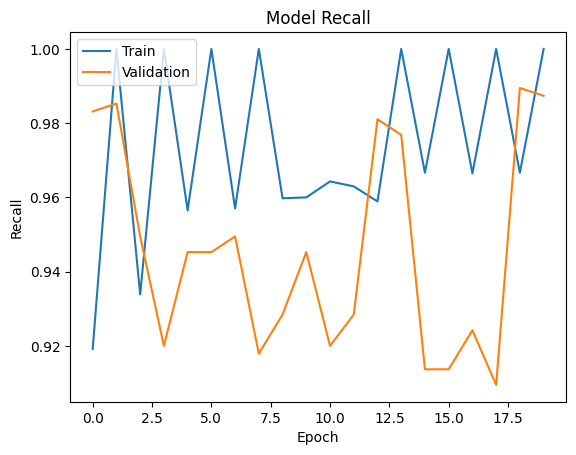

In [41]:
plt.plot(history_3.history['Recall'])
plt.plot(history_3.history['val_Recall'])
plt.title('Model Recall')
plt.ylabel('Recall')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


In [ ]:
#Observation : the recall curve for both train and valodation data are both zig-zag, flutuations between .91 and 1.00 .
# Adding the Feed forward head made the optimization path more unstable compared to simpler models.

# Adding feed forward layer provided more power but introduced instablity.

In [42]:
model_3_train_perf = model_performance_classification(model_3, X_train_normalized,y_train)

print("Train performance metrics")
print(model_3_train_perf)

91/91 ━━━━━━━━━━━━━━━━━━━━ 15s 142ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.939037  0.939037   0.939037  0.939037


In [ ]:
#Observation : All the metrics are almost the same 93.9%

91/91 ━━━━━━━━━━━━━━━━━━━━ 14s 147ms/step


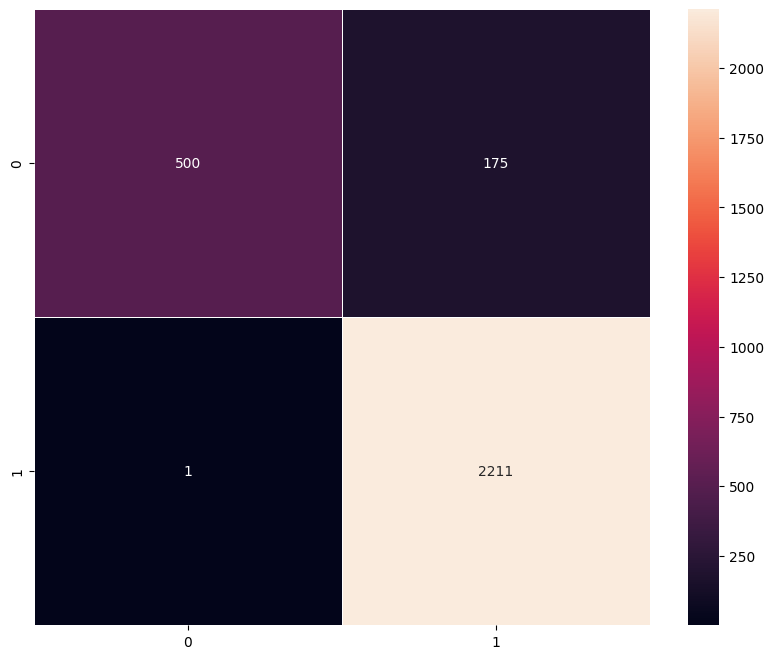

In [43]:
plot_confusion_matrix(model_3,X_train_normalized,y_train)

In [ ]:
#Observation :
# True positive - There are 2211 images where workers were wering helmets and the model correctly identified.
# True Negative - There are 500 iamges where the workers were not wearing helmets and the model correctly identified them as not having helmets.
# False Positive - For 175 images without helmets were mistakenly labeled "With Helmet."
# False Negative - For 1 images wearing helmets were labeled "Without Helmet."

# In the training set, the model missed only 1 helmet (False Negative), showing that the added Feed-Forward layers are extremely effective at memorizing the "With Helmet" features.
# But the 175 False Postivies, the model is struggling in training.

In [44]:
model_3_valid_perf = model_performance_classification(model_3, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_3_valid_perf)

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.869144  0.869144   0.869144  0.869144


In [ ]:
# Observation : There is significant drop in performance between training and validation set by adding Feed Forward Head to VGG-16.
# The validation metrics are 7 % lower than training metrics . 93.9% --> 86.9%, representing training model is overfitting.

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step


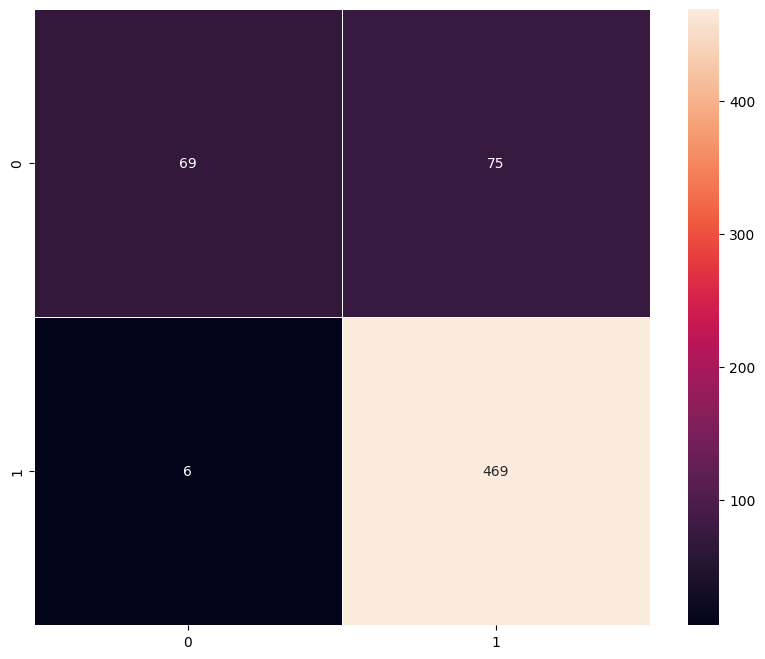

In [45]:
plot_confusion_matrix(model_3,X_val_normalized,y_val)

In [ ]:
#Observation :
# True positive - There are 469 images where workers were wering helmets and the model correctly identified.
# True Negative - There are 69 iamges where the workers were not wearing helmets and the model correctly identified them as not having helmets.
# False Negative - For 6 images, the model said no helmet but they had one .
# False positive - For 75 images, the model said with helmet but there didn't have one.

# The 75 False Positives are your biggest concern.  In a real-world deployment, as these 75 people who would be allowed onto a site without protection because the AI mistakenly thought they were wearing a helmet.

#### Visualizing the predictions

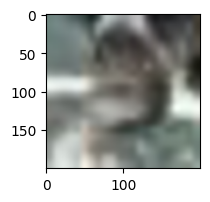

Predicted Label: 1
True Label: 0


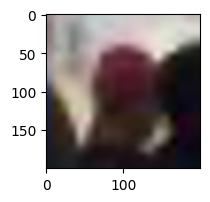

Predicted Label: 1
True Label: 1


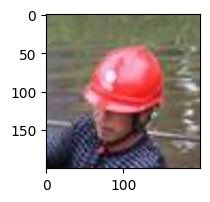

Predicted Label: 1
True Label: 1


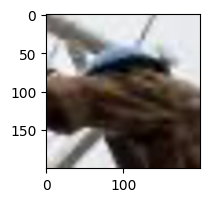

Predicted Label: 1
True Label: 1


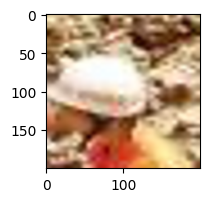

Predicted Label: 1
True Label: 1


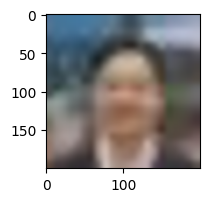

Predicted Label: 1
True Label: 0


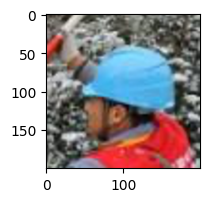

Predicted Label: 1
True Label: 1


In [84]:
# For index 12
# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[12])
plt.show()
pred_12 = (model_3.predict(X_val_normalized[12].reshape(1,200,200,3), verbose=0) > 0.5).astype(int)
print('Predicted Label:', enc.inverse_transform(pred_12)[0])
print('True Label:', enc.inverse_transform(y_val_encoded)[12])

# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[33])
plt.show()
pred_33 = (model_3.predict(X_val_normalized[33].reshape(1,200,200,3), verbose=0) > 0.5).astype(int)
print('Predicted Label:', enc.inverse_transform(pred_33)[0])
print('True Label:', enc.inverse_transform(y_val_encoded)[33])

# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[2])
plt.show()
pred_2 = (model_3.predict(X_val_normalized[33].reshape(1,200,200,3), verbose=0) > 0.5).astype(int)
print('Predicted Label:', enc.inverse_transform(pred_2)[0])
print('True Label:', enc.inverse_transform(y_val_encoded)[2])

# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[100])
plt.show()
pred_100 = (model_3.predict(X_val_normalized[100].reshape(1,200,200,3), verbose=0) > 0.5).astype(int)
print('Predicted Label:', enc.inverse_transform(pred_100)[0])
print('True Label:', enc.inverse_transform(y_val_encoded)[100])

# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[200])
plt.show()
pred_200 = (model_3.predict(X_val_normalized[33].reshape(1,200,200,3), verbose=0) > 0.5).astype(int)
print('Predicted Label:', enc.inverse_transform(pred_200)[0])
print('True Label:', enc.inverse_transform(y_val_encoded)[200])

# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[289])
plt.show()
pred_289 = (model_3.predict(X_val_normalized[289].reshape(1,200,200,3), verbose=0) > 0.5).astype(int)
print('Predicted Label:', enc.inverse_transform(pred_200)[0])
print('True Label:', enc.inverse_transform(y_val_encoded)[289])

# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[360])
plt.show()
pred_360 = (model_3.predict(X_val_normalized[33].reshape(1,200,200,3), verbose=0) > 0.5).astype(int)
print('Predicted Label:', enc.inverse_transform(pred_360)[0])
print('True Label:', enc.inverse_transform(y_val_encoded)[360])


In [ ]:
# Observation : For the images with helmet (33,2,100,360) and without helmet (12,289) the model is predicting with helmet.
# Model 3 shows a strong tendency to predict "With Helmet" for almost every case.

# the model has not learned to distinguish the no helmet class effectively.

## Model 4: Transfer Learning with VGG-16 (Base + FFNN + Data Augmentation)

- In most of the real-world case studies, it is challenging to acquire a large number of images and then train CNNs.
- To overcome this problem, one approach we might consider is **Data Augmentation**.
- CNNs have the property of **translational invariance**, which means they can recognise an object even if its appearance shifts translationally in some way. - Taking this attribute into account, we can augment the images using the techniques listed below

    -  Horizontal Flip (should be set to True/False)
    -  Vertical Flip (should be set to True/False)
    -  Height Shift (should be between 0 and 1)
    -  Width Shift (should be between 0 and 1)
    -  Rotation (should be between 0 and 180)
    -  Shear (should be between 0 and 1)
    -  Zoom (should be between 0 and 1) etc.

Remember, **data augmentation should not be used in the validation/test data set**.

In [47]:
model_4 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_4.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_4.add(Flatten())

#Adding the Feed Forward neural network
model_4.add(Dense(256,activation='relu'))
model_4.add(Dropout(rate=0.4))
model_4.add(Dense(32,activation='relu'))

# Adding a dense output layer
model_4.add(Dense(1, activation='sigmoid'))

In [49]:
opt=Adam(learning_rate=0.001)
# Compile model
model_4.compile(optimizer=opt,   loss=keras.losses.BinaryCrossentropy(), metrics=["Recall"])

In [50]:
# Generating the summary of the model
model_4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,441,793 (74.16 MB)

 Trainable params: 4,727,105 (18.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [51]:
# Applying data augmentation
# Applying data augmentation
train_datagen = ImageDataGenerator(
    rotation_range=20,
    fill_mode='nearest',
    width_shift_range=0.20,
    height_shift_range=0.20,
    shear_range=0.30,
    zoom_range=0.40
)



In [ ]:
# Observation : In addition to adding Feed forward layer , we are adding data augmentation.
# Rotating the image, doing width and height shift . this is increase the dataset quantity.

In [52]:
history_4 = model_4.fit(train_datagen.flow(X_train_normalized,y_train,
                                       batch_size=32, #Complete the code to define the batch size
                                       seed=42,
                                       shuffle=False),
                    epochs=epochs,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 41s 441ms/step - Recall: 0.9086 - loss: 0.6274 - val_Recall: 0.9242 - val_loss: 0.4215
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - Recall: 0.9130 - loss: 0.5825 - val_Recall: 0.7811 - val_loss: 0.4680
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 38s 423ms/step - Recall: 0.9208 - loss: 0.4282 - val_Recall: 0.9368 - val_loss: 0.3299
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - Recall: 0.9286 - loss: 0.3733 - val_Recall: 0.9389 - val_loss: 0.3318
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 38s 424ms/step - Recall: 0.9301 - loss: 0.4136 - val_Recall: 0.9537 - val_loss: 0.3104
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - Recall: 0.9091 - loss: 0.7743 - val_Recall: 0.9263 - val_loss: 0.3142
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 38s 422ms/step - Recall: 0.9278 - loss: 0.3890 - val_Recall: 0.9011 - val_loss: 0.3092
Epoch 8/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - Recall: 0.9600 - loss: 0.3742 - val_Recall: 0.9179 - val_loss: 0.3034
Epoch 9/

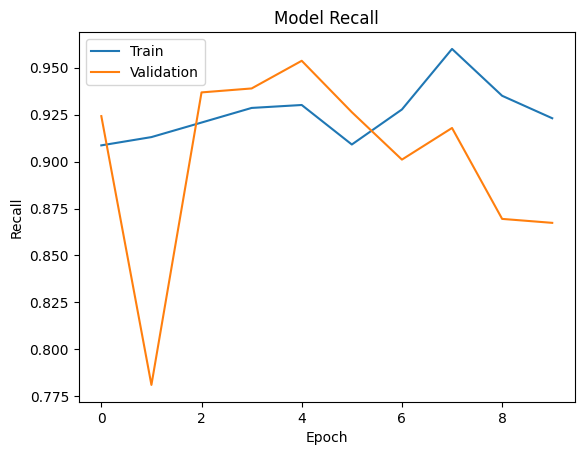

In [53]:
plt.plot(history_4.history['Recall']) #Complete the code to plot the train metrics
plt.plot(history_4.history['val_Recall']) #Complete the code to plot the validation data metrics
plt.title('Model Recall') #Complete the code to define the title for the plot
plt.ylabel('Recall') #Complete the code to define the label for the y-axis
plt.xlabel('Epoch') #Complete the code to define the label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


In [54]:
model_4_train_perf = model_performance_classification(model_4, X_train_normalized,y_train)

print("Train performance metrics")
print(model_4_train_perf)

91/91 ━━━━━━━━━━━━━━━━━━━━ 15s 147ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.875649  0.875649   0.875649  0.875649


91/91 ━━━━━━━━━━━━━━━━━━━━ 14s 140ms/step


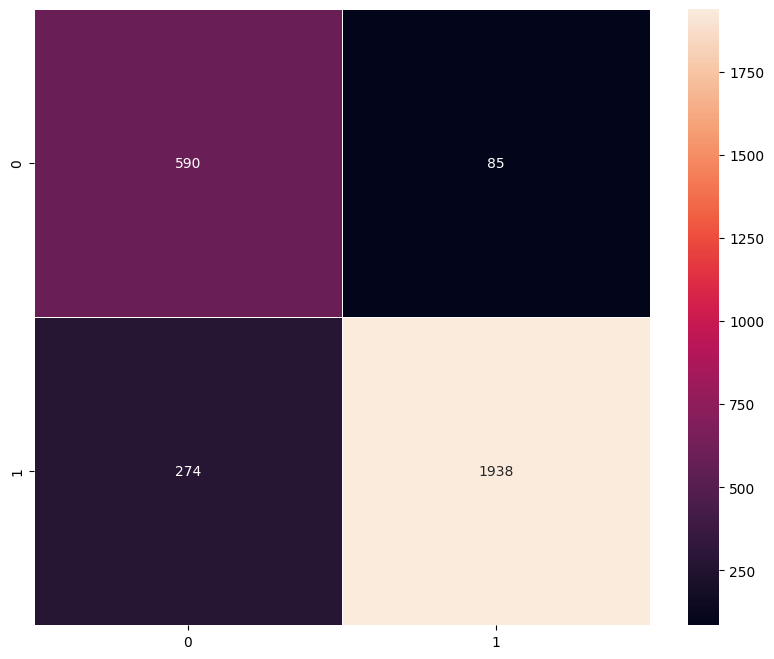

In [55]:
plot_confusion_matrix(model_4,X_train_normalized,y_train)

In [56]:
model_4_valid_perf = model_performance_classification(model_4, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_4_valid_perf)

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 138ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.857835  0.857835   0.857835  0.857835


20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step


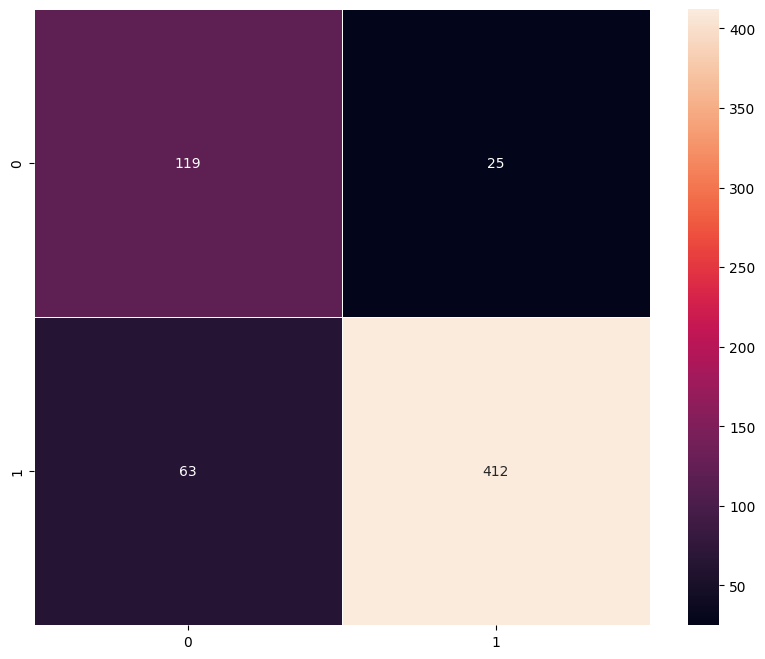

In [57]:
plot_confusion_matrix(model_4,X_val_normalized,y_val)

#### Visualizing the predictions

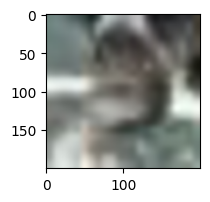

Predicted Label: 0
True Label: 0


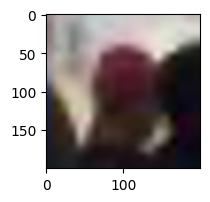

Predicted Label: 0
True Label: 1


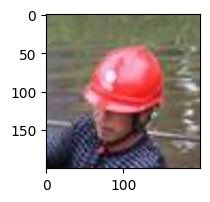

Predicted Label: 0
True Label: 1


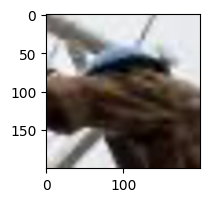

Predicted Label: 0
True Label: 1


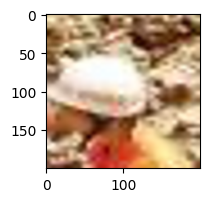

Predicted Label: 0
True Label: 1


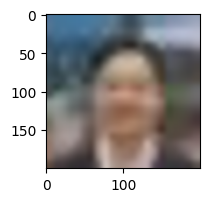

Predicted Label: 0
True Label: 0


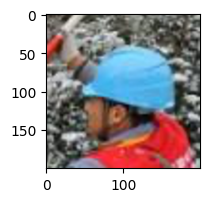

Predicted Label: 0
True Label: 1


In [85]:
# For index 12
# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[12])
plt.show()
pred_12 = (model_4.predict(X_val_normalized[12].reshape(1,200,200,3), verbose=0) > 0.5).astype(int)
print('Predicted Label:', enc.inverse_transform(pred_12)[0])
print('True Label:', enc.inverse_transform(y_val_encoded)[12])

# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[33])
plt.show()
pred_33 = (model_4.predict(X_val_normalized[33].reshape(1,200,200,3), verbose=0) > 0.5).astype(int)
print('Predicted Label:', enc.inverse_transform(pred_33)[0])
print('True Label:', enc.inverse_transform(y_val_encoded)[33])

# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[2])
plt.show()
pred_2 = (model_4.predict(X_val_normalized[33].reshape(1,200,200,3), verbose=0) > 0.5).astype(int)
print('Predicted Label:', enc.inverse_transform(pred_2)[0])
print('True Label:', enc.inverse_transform(y_val_encoded)[2])

# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[100])
plt.show()
pred_100 = (model_4.predict(X_val_normalized[100].reshape(1,200,200,3), verbose=0) > 0.5).astype(int)
print('Predicted Label:', enc.inverse_transform(pred_100)[0])
print('True Label:', enc.inverse_transform(y_val_encoded)[100])

# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[200])
plt.show()
pred_200 = (model_4.predict(X_val_normalized[33].reshape(1,200,200,3), verbose=0) > 0.5).astype(int)
print('Predicted Label:', enc.inverse_transform(pred_200)[0])
print('True Label:', enc.inverse_transform(y_val_encoded)[200])

# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[289])
plt.show()
pred_289 = (model_4.predict(X_val_normalized[289].reshape(1,200,200,3), verbose=0) > 0.5).astype(int)
print('Predicted Label:', enc.inverse_transform(pred_200)[0])
print('True Label:', enc.inverse_transform(y_val_encoded)[289])

# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_val[360])
plt.show()
pred_360 = (model_4.predict(X_val_normalized[33].reshape(1,200,200,3), verbose=0) > 0.5).astype(int)
print('Predicted Label:', enc.inverse_transform(pred_360)[0])
print('True Label:', enc.inverse_transform(y_val_encoded)[360])

In [ ]:
# Observation : Model 4 is much better at identifying actual violations (Indices 12 and 289), proving that data augmentation helped it learn what a "No Helmet" case actually looks like.
# But the model has become "too skeptical," incorrectly labeling almost all helmeted workers (Indices 2, 33, 100, 360) as having no helmet.

# **Model Performance Comparison and Final Model Selection**

In [67]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        model_1_train_perf.T,
        model_2_train_perf.T,
        model_3_train_perf.T,
        model_4_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Simple Convolutional Neural Network (CNN)","VGG-16 (Base)","VGG-16 (Base+FFNN)","VGG-16 (Base+FFNN+Data Aug)"
]

In [68]:
models_valid_comp_df = pd.concat(
    [
        model_1_valid_perf.T,
        model_2_valid_perf.T,
        model_3_valid_perf.T,
        model_4_valid_perf.T

    ],
    axis=1,
)
models_valid_comp_df.columns = [
 "Simple Convolutional Neural Network (CNN)","VGG-16 (Base)","VGG-16 (Base+FFNN)","VGG-16 (Base+FFNN+Data Aug)"
]

In [69]:
models_train_comp_df

,Simple Convolutional Neural Network (CNN),VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,0.930031,0.965016,0.939037,0.875649
Recall,0.930031,0.965016,0.939037,0.875649
Precision,0.930031,0.965016,0.939037,0.875649
F1 Score,0.930031,0.965016,0.939037,0.875649


In [70]:
models_valid_comp_df

,Simple Convolutional Neural Network (CNN),VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,0.914378,0.878837,0.869144,0.857835
Recall,0.914378,0.878837,0.869144,0.857835
Precision,0.914378,0.878837,0.869144,0.857835
F1 Score,0.914378,0.878837,0.869144,0.857835


In [71]:
models_train_comp_df - models_valid_comp_df

,Simple Convolutional Neural Network (CNN),VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,0.015653,0.086179,0.069893,0.017814
Recall,0.015653,0.086179,0.069893,0.017814
Precision,0.015653,0.086179,0.069893,0.017814
F1 Score,0.015653,0.086179,0.069893,0.017814


In [ ]:
# Observation : All four models were tested with the test set, which had not been used during training or validation.
# The baseline model has accuracy, recall, precision and F1 score close to 91.4 %
# The VGG-16 model achieves superior training performance with Accuracy, Recall, Precision, and F1-score all near 96.5% , it fails to maintain this level on unseen data.
# The VGG-16 with FeedForward Neural Network added custom decision making head but showed extreme zig zag  and has the metrics close to 86.9%.
# The final model where data augmentation was added to increase the dataset successfully fixed the overfitting gap but the overall metrics dropped to 85.7%.

# Looking at the validation dataset, Model 1 the basic CNN provides the best balanace with high performance and did better with validation dataset.
# Based on the results from validation dataset, I will choose the Model 1 , the classic CNN to perform on the test data set.

## Test Performance

In [72]:
model_test_perf = model_performance_classification(model_1, X_test_normalized,y_test)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


In [73]:
model_test_perf

,Accuracy,Recall,Precision,F1 Score
0,0.894992,0.894992,0.894992,0.894992


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


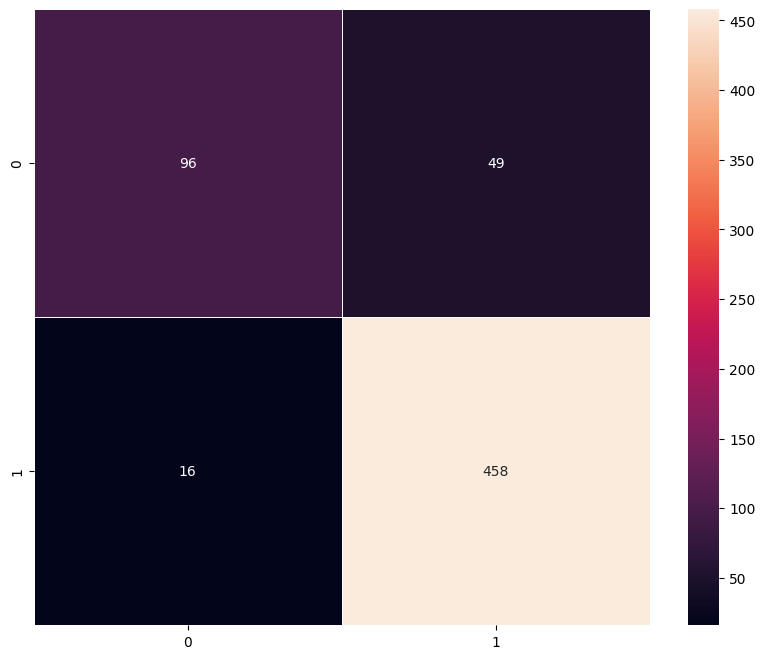

In [74]:
plot_confusion_matrix(model_1, X_test_normalized,y_test)

In [ ]:
# Observation :
# Accuracy 89.5% - The model correctly classifies nearly 90% of the images in the test set, showing strong reliability on completely new data.
# Recall 89.5% - This high recall score is crucial for SafeGuard Corp, as it indicates a high success rate in identifying workers following safety protocols.
# Precision 89.5% - The model maintains a high "trust" level; when it says a helmet is present, it is correct almost 90% of the time.
# F-score 89.5% - The perfect balance between Precision and Recall confirms the model is robust and not biased toward just one class.

# The drop from 91.4% Validation Accuracy to 89.5% Test Accuracy is very small (~1.9%), proving that Model 1 is not overfitted and will perform consistently in a real-world factory environment.
# Achieving ~90% across all metrics on unseen data makes this the most dependable choice for SafeGuard Corp compared to the deeper VGG-16 models.

# Since the performance is almost stable for the inseen tedt data. The CNN model is safe to use in pilot phase .

# **Actionable Insights & Recommendations**

Actionaable Insights :
- The CNN Model is most viable to deploy .   
- Unlike the complex VGG-16 models, it maintains a high test accuracy (89.5%) with a very low generalization gap (1.6%), proving it can handle unseen images effectively.
- The 76/24 class distribution significantly influenced the transfer learning models, causing them to overfit on the "With Helmet" class.
- While Data Augmentation helped stabilize the model, it requires further tuning to avoid high false-alarm rates.   
- Visual analysis shows the system occasionally struggles with low-contrast environments and ambiguous headwear (like caps). This indicates that while the model understands "helmet" shapes.
- Recall is used  as primary metric is a strategic choice based on the "Safety First" nature of the problem. Recall ensures that the model is extremely sensitive to catching every possible safety violation. It minimizes the chances of a "miss".

Recommendations:

- Deploy the model 1 CNN in controlled phase and test at single entrance point.
- Capture more  images with helmets.
- Capture more images without helmets in the active work zone.
- Add different camera angles , take images at different light exposure.
- Data Augmentation can be performed more and dropout_rate can be changed to improve the model performance.
-  Retrain the models with the new captured images and check the metrics.

<font size=5 color='blue'>Power Ahead!</font>
___